# Evaluating Sternberg Rate Models

Trained 3/12/26, using `train_interleaved_models.sh`

`python main_interleaved.py --gpu 0 --gpu_frac 0.20 --n_trials 40000 --mode train \
--N 200 --P_inh 0.20 --som_N 0 --apply_dale True --gain 1.5 --task sternberg \
--load_proportion 0.5 \
--act sigmoid --loss_fn l2 --decay_taus 4 25 --jitter_onset 5 --jitter_delay 3 \
--output_dir ~/Documents/renee/`

jitter onset 5, delay 3. 40k trials. training delay=10.

In [1]:
import os, scipy.io 
import numpy as np 
import matplotlib.pyplot as plt 

import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate/')

import model

2026-03-12 22:26:26.214029: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 22:26:26.222807: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-12 22:26:26.231933: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-12 22:26:26.234641: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-12 22:26:26.242676: I tensorflow/core/platform/cpu_feature_guar

Instructions for updating:
non-resource variables are not supported in the long term


## load models, N=200

In [2]:
import glob

def find_files(path, pattern):
    """
    Find all files matching the given glob pattern in the specified path
    Args:
        path (str): path to directory
        pattern (str): glob pattern (e.g., '*.xlsx', '*_sorted_new.mat')
    Returns:
        list of file paths
    """
    return glob.glob(os.path.join(path, pattern))

In [3]:
model_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

model_names = find_files(model_dir, '*.mat')
print(len(model_names))
print(model_names)

16
['/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_200_Jitter_5_3_2026_03_12_220050.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_200_Jitter_5_3_2026_03_12_211325.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_200_Jitter_5_3_2026_03_12_221730.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_200_Jitter_5_3_2026_03_12_220836.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_200_Jitter_5_3_2026_03_12_192628.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_200_Jitter_5_3_2026_03_12_212103.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_200_Jitter_5_3_2026_03_12_203856.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_200_Jitter_5_3_2026_03_12_220451.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_ste

In [4]:
perfs_low = []
perfs_high = []
train_tr = []

for model_name in model_names:
    mat_data = scipy.io.loadmat(os.path.join(model_dir, model_name))
    print(model_name)
    perfs_low.append(mat_data["eval_perfs"][0][0])
    perfs_high.append(mat_data["eval_perfs"][0][1])
    train_tr.append(mat_data["tr"][0])
    print(f'Training trials: {mat_data["tr"][0]}')
    print(f'Load 1 perf: {mat_data["eval_perfs"][0][0]}, Load 3 perf: {mat_data["eval_perfs"][0][1]}')
    print(f'Ending p_low: {mat_data["p_low"][0]}')


/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_200_Jitter_5_3_2026_03_12_220050.mat
Training trials: [39999]
Load 1 perf: 0.78, Load 3 perf: 0.84
Ending p_low: [0.5]
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_200_Jitter_5_3_2026_03_12_211325.mat
Training trials: [27301]
Load 1 perf: 0.97, Load 3 perf: 0.87
Ending p_low: [0.5]
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_200_Jitter_5_3_2026_03_12_221730.mat
Training trials: [39999]
Load 1 perf: 0.77, Load 3 perf: 0.67
Ending p_low: [0.5]
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_200_Jitter_5_3_2026_03_12_220836.mat
Training trials: [39999]
Load 1 perf: 0.86, Load 3 perf: 0.81
Ending p_low: [0.5]
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_200_Jitter_5_3_2026_03_12_192628.mat
Training trials: [24401]
Load 1 perf: 0.96, Load 3 perf: 0.85
Ending p_low: [0.5]
/home/nuttidalab/Document

### model eval

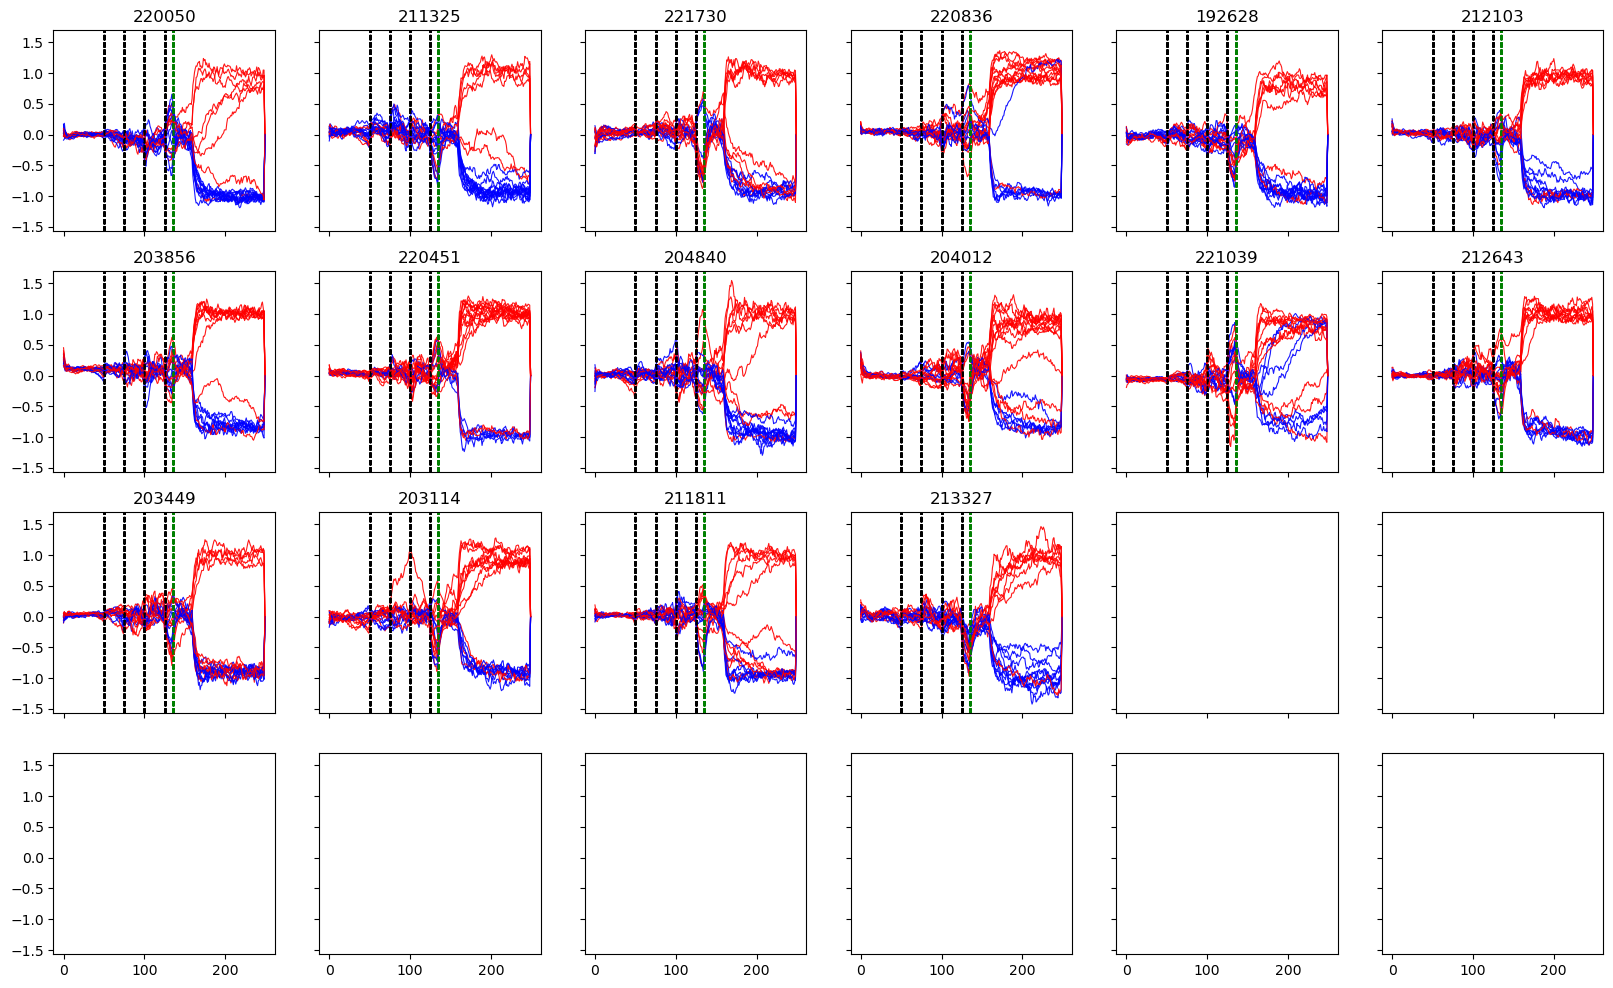

In [5]:
from model import generate_input_stim_sternberg

settings = {
            'T': 250, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 10, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 3, # initialize with load 3
            }

stim_on = mat_data['stim_on_tr'][0]
stim_dur = mat_data['stim_dur_tr'][0]
delay = mat_data['delay_tr'][0]

n_trials = 20
fig, axs = plt.subplots(4, 6, figsize=(20, 12), sharex=True, sharey=True)
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    for j in range(n_trials):
        u_high, label = model.generate_input_stim_sternberg(settings)
        x, r, o, _ = model.eval_tf(model_dir=model_name, settings=settings, u=u_high)
        
        axs[i].plot(o, c=['r' if label == 1 else 'b'][0], alpha=0.9, linewidth = 0.8)
        axs[i].axvline(x=stim_on, color='k', linestyle='--', linewidth=1)
        for k in range(settings['load']):
            axs[i].axvline(x=stim_on + (k+1)*stim_dur, color='k', linestyle='--', linewidth=1)
        axs[i].axvline(x=stim_on + stim_dur*settings['load'] + settings['delay'], color='g', linestyle='--', linewidth=1)
    axs[i].set_title(f'{model_name[-10:-4]}')
plt.show()

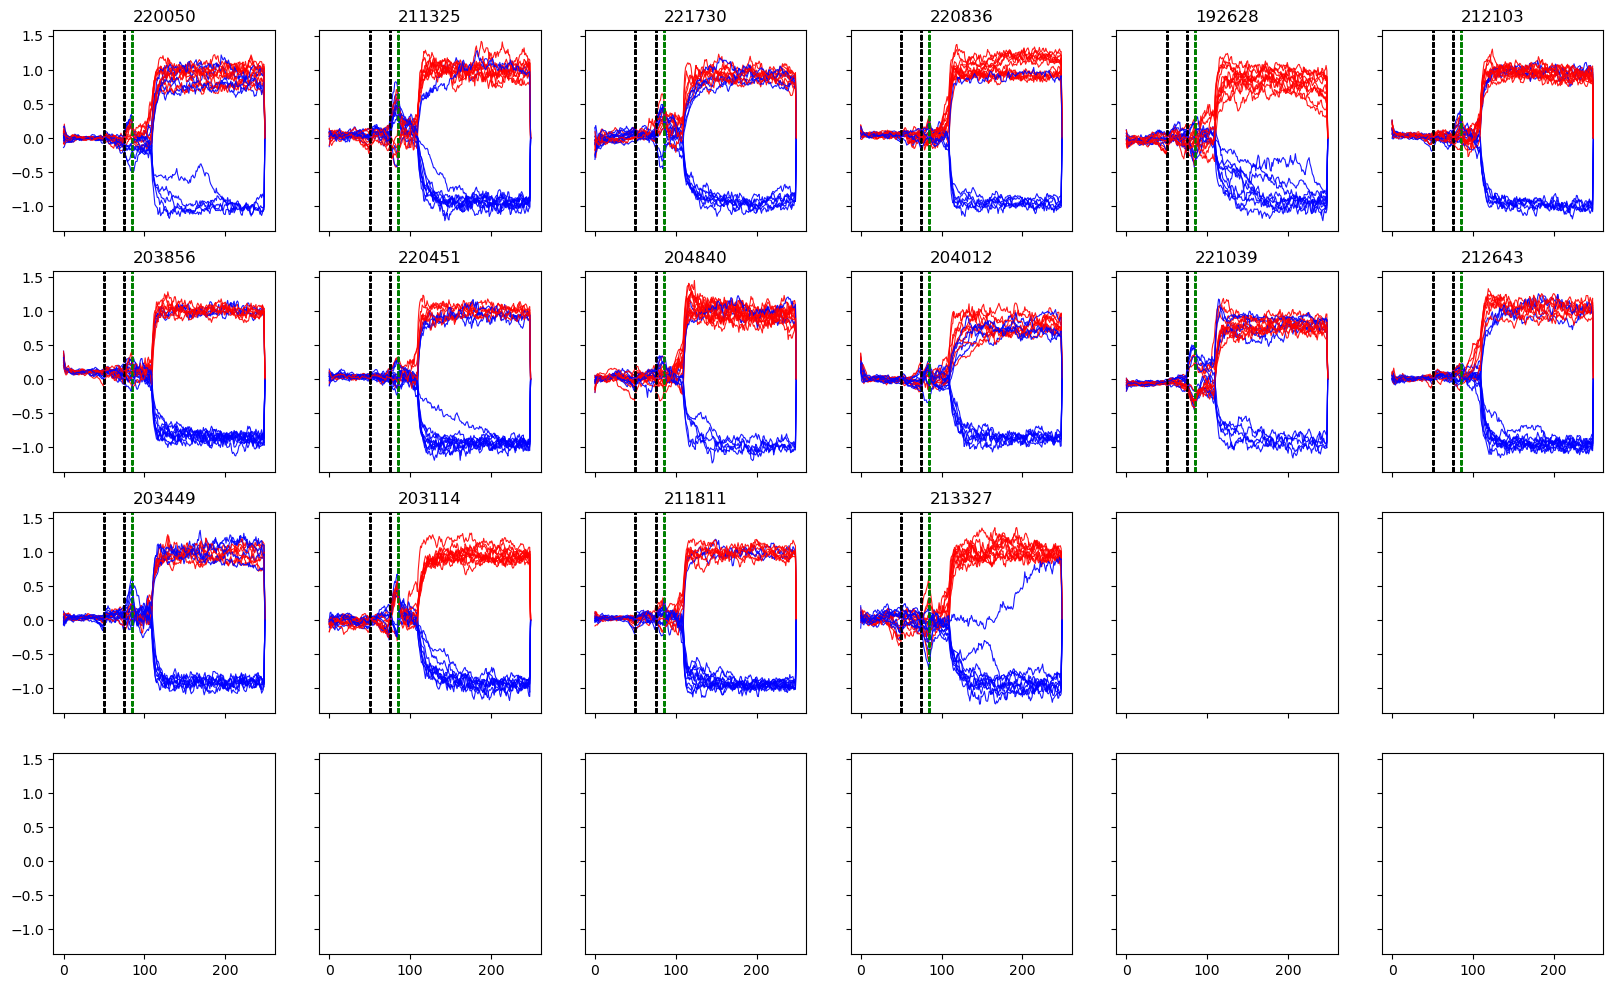

In [6]:
settings = {
            'T': 250, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 10, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 1, # initialize with load 1
            }

stim_on = mat_data['stim_on_tr'][0]
stim_dur = mat_data['stim_dur_tr'][0]
delay = mat_data['delay_tr'][0]

n_trials = 20
fig, axs = plt.subplots(4, 6, figsize=(20, 12), sharex=True, sharey=True)
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    for j in range(n_trials):
        u_low, label = model.generate_input_stim_sternberg(settings)
        x, r, o, _ = model.eval_tf(model_dir=model_name, settings=settings, u=u_low)
        
        axs[i].plot(o, c=['r' if label == 1 else 'b'][0], alpha=0.9, linewidth = 0.8)
        axs[i].axvline(x=stim_on, color='k', linestyle='--', linewidth=1)
        for k in range(settings['load']):
            axs[i].axvline(x=stim_on + (k+1)*stim_dur, color='k', linestyle='--', linewidth=1)
        axs[i].axvline(x=stim_on + stim_dur*settings['load'] + settings['delay'], color='g', linestyle='--', linewidth=1)
    axs[i].set_title(f'{model_name[-10:-4]}')
plt.show()

### now extending delay, as a test

In [10]:
for i, tr in enumerate(train_tr):
    if tr < 39999:
        print(f'{model_names[i]}: {tr}')
        print(f'Load 1 perf: {perfs_low[i]}, Load 3 perf: {perfs_high[i]}')

/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_200_Jitter_5_3_2026_03_12_211325.mat: [27301]
Load 1 perf: 0.97, Load 3 perf: 0.87
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_200_Jitter_5_3_2026_03_12_192628.mat: [24401]
Load 1 perf: 0.96, Load 3 perf: 0.85
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_200_Jitter_5_3_2026_03_12_203114.mat: [33501]
Load 1 perf: 0.96, Load 3 perf: 0.82


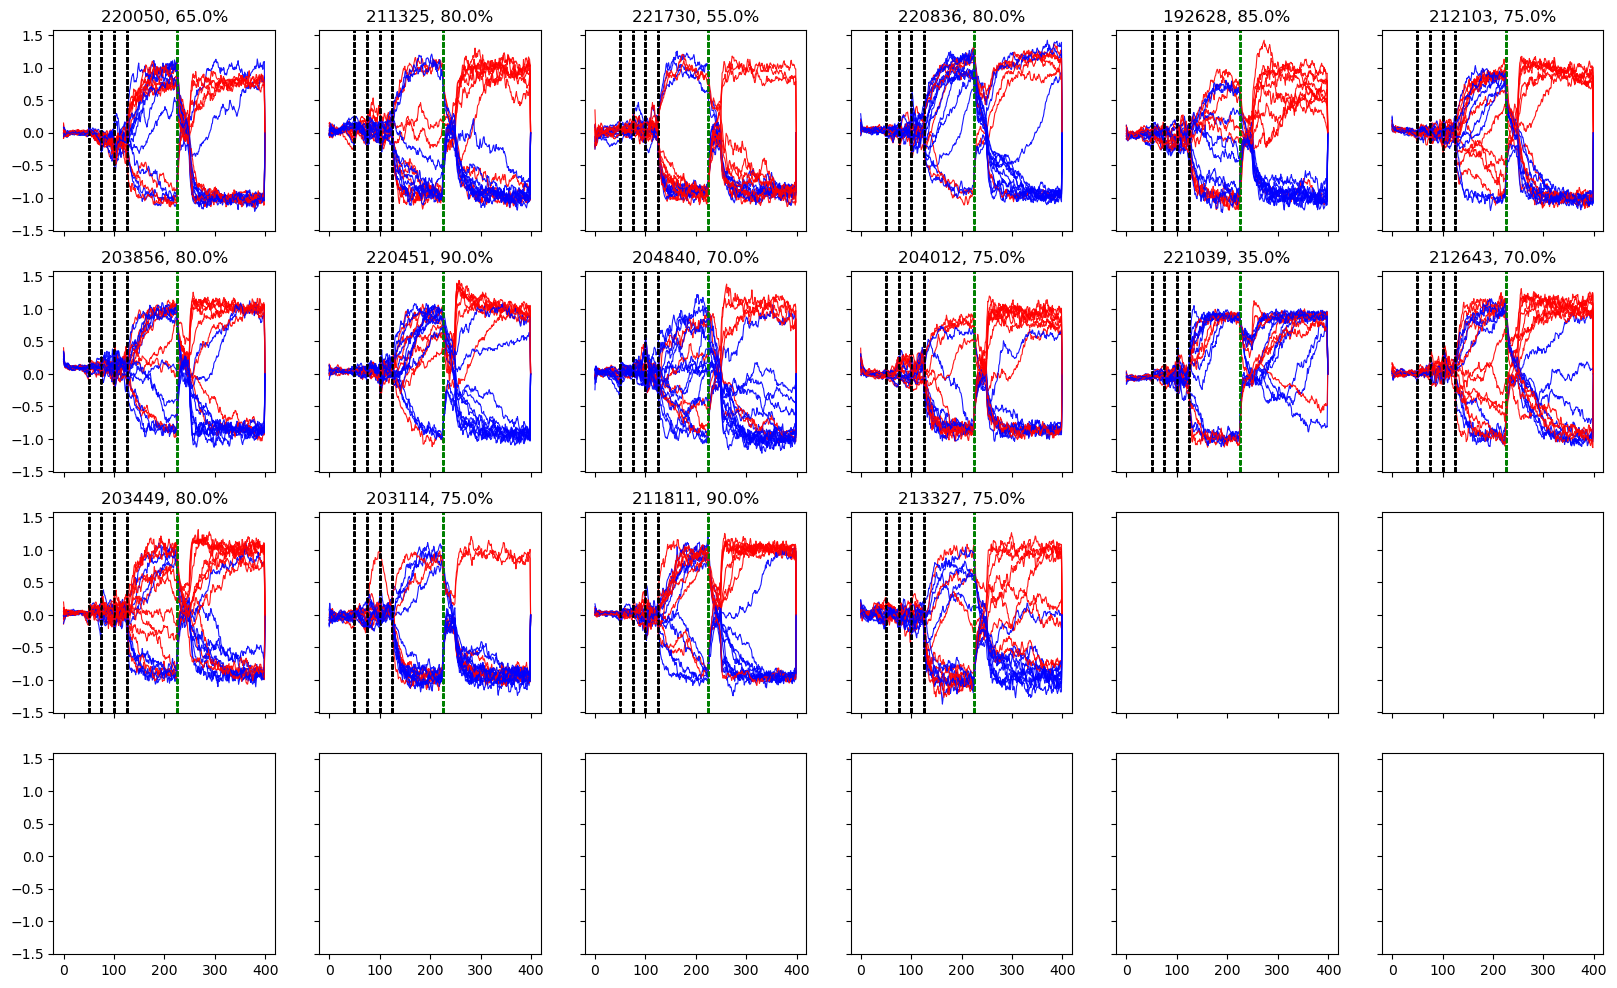

In [7]:
from model import generate_input_stim_sternberg

settings = {
            'T': 400, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 100, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 3, # initialize with load 1, but will alternate with 3
            }

stim_on = mat_data['stim_on_tr'][0]
stim_dur = mat_data['stim_dur_tr'][0]
delay = mat_data['delay_tr'][0]

n_trials = 20
fig, axs = plt.subplots(4, 6, figsize=(20, 12), sharex=True, sharey=True)
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    resp_onset = settings['stim_on'] + settings['load']*settings['stim_dur'] + settings['stim_dur'] + settings['delay']
    eval_perf = np.zeros(n_trials)
    for j in range(n_trials):
        u_high, label = model.generate_input_stim_sternberg(settings)
        x, r, o, _ = model.eval_tf(model_dir=model_name, settings=settings, u=u_high)
        if label == 1: # same
            if np.max(o[resp_onset:]) > 0.7:
                eval_perf[j] = 1
        else:
            if np.min(o[resp_onset:]) < -0.7:
                eval_perf[j] = 1
        
        axs[i].plot(o, c=['r' if label == 1 else 'b'][0], alpha=0.9, linewidth = 0.8)
        axs[i].axvline(x=stim_on, color='k', linestyle='--', linewidth=1)
        for k in range(settings['load']):
            axs[i].axvline(x=stim_on + (k+1)*stim_dur, color='k', linestyle='--', linewidth=1)
        axs[i].axvline(x=stim_on + stim_dur*settings['load'] + settings['delay'], color='g', linestyle='--', linewidth=1)
    axs[i].set_title(f'{model_name[-10:-4]}, {np.mean(eval_perf)*100:.1f}%')
plt.show()

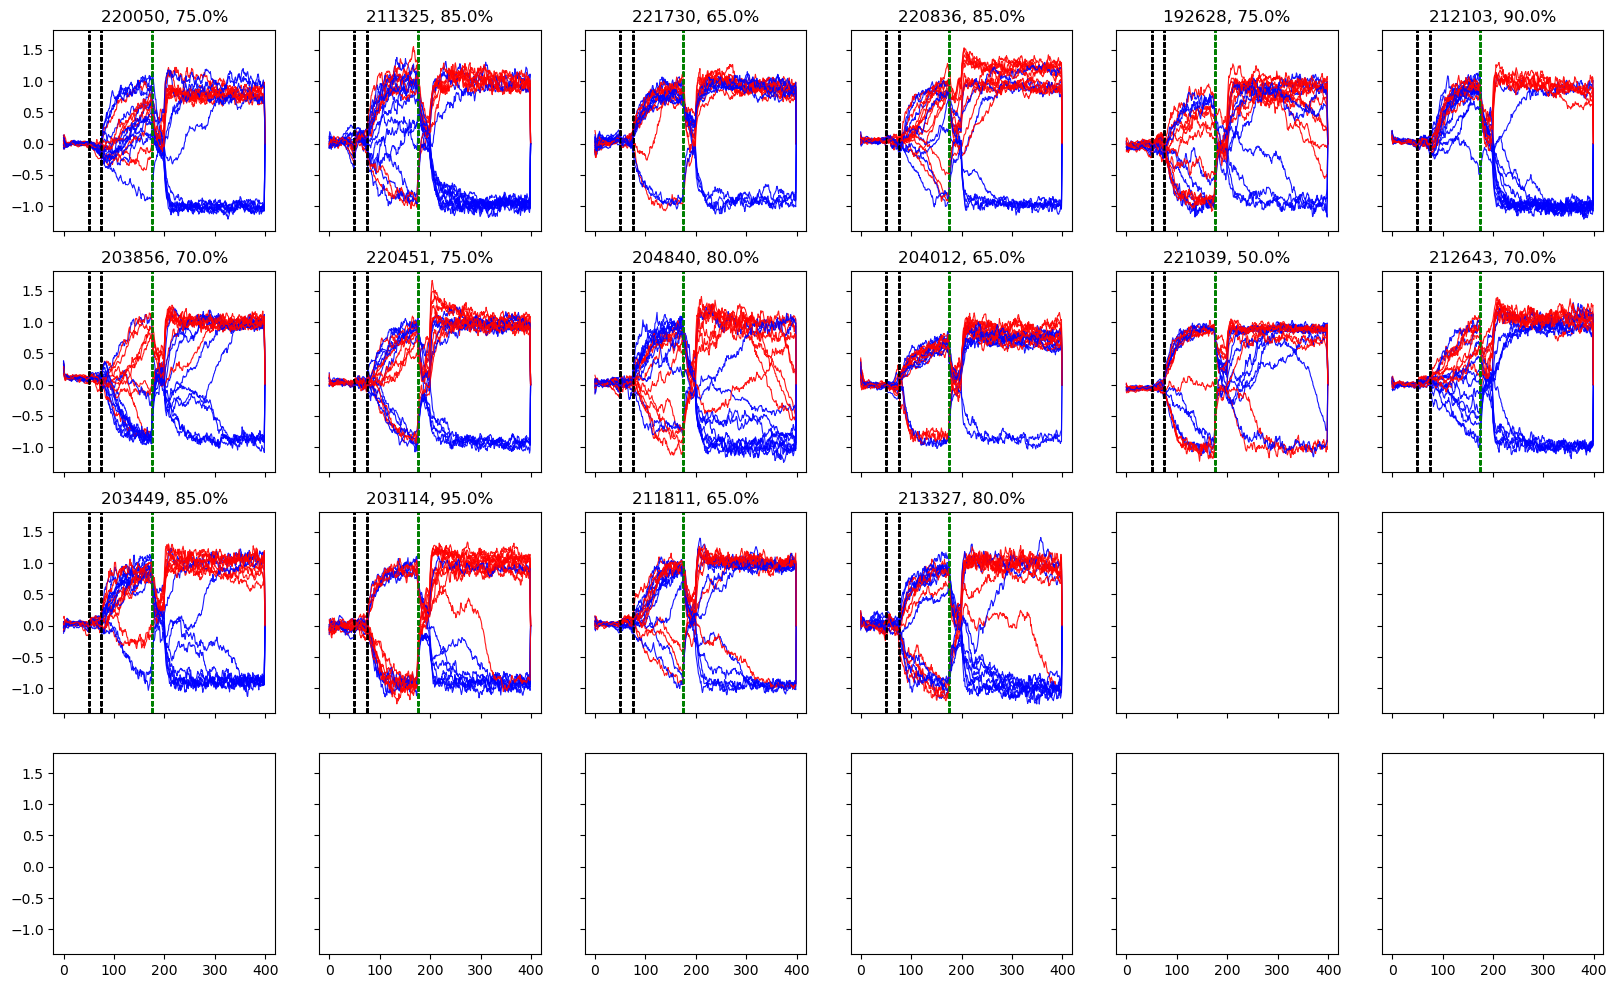

In [8]:
settings = {
            'T': 400, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 100, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 1, # initialize with load 1, but will alternate with 3
            }

stim_on = mat_data['stim_on_tr'][0]
stim_dur = mat_data['stim_dur_tr'][0]
delay = mat_data['delay_tr'][0]

n_trials = 20
fig, axs = plt.subplots(4, 6, figsize=(20, 12), sharex=True, sharey=True)
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    resp_onset = settings['stim_on'] + settings['load']*settings['stim_dur'] + settings['stim_dur'] + settings['delay']
    eval_perf = np.zeros(n_trials)
    for j in range(n_trials):
        u_low, label = model.generate_input_stim_sternberg(settings)
        x, r, o, _ = model.eval_tf(model_dir=model_name, settings=settings, u=u_low)

        if label == 1: # same
            if np.max(o[resp_onset:]) > 0.7:
                eval_perf[j] = 1
        else:
            if np.min(o[resp_onset:]) < -0.7:
                eval_perf[j] = 1
        
        axs[i].plot(o, c=['r' if label == 1 else 'b'][0], alpha=0.9, linewidth = 0.8)
        axs[i].axvline(x=stim_on, color='k', linestyle='--', linewidth=1)
        for k in range(settings['load']):
            axs[i].axvline(x=stim_on + (k+1)*stim_dur, color='k', linestyle='--', linewidth=1)
        axs[i].axvline(x=stim_on + stim_dur*settings['load'] + settings['delay'], color='g', linestyle='--', linewidth=1)
    axs[i].set_title(f'{model_name[-10:-4]}, {np.mean(eval_perf)*100:.1f}%')
plt.show()

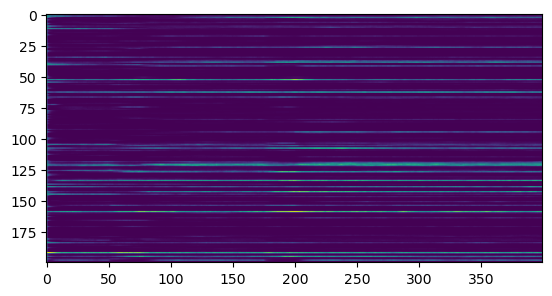

In [11]:
plt.imshow(r)

## the N=400 models now

In [1]:
import os, scipy.io 
import numpy as np 
import matplotlib.pyplot as plt 

import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate/')

import model

2026-03-13 17:56:15.522646: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 17:56:15.534552: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-13 17:56:15.547102: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-13 17:56:15.550878: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-13 17:56:15.561874: I tensorflow/core/platform/cpu_feature_guar

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
import glob

def find_files(path, pattern):
    """
    Find all files matching the given glob pattern in the specified path
    Args:
        path (str): path to directory
        pattern (str): glob pattern (e.g., '*.xlsx', '*_sorted_new.mat')
    Returns:
        list of file paths
    """
    return glob.glob(os.path.join(path, pattern))

In [3]:
model_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

model_names = find_files(model_dir, '*N_400*.mat')
print(len(model_names))
print(model_names)

20
['/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_060322.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_074218.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_031610.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_065015.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_094059.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_030754.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_105442.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_134141.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_ste

In [4]:
perfs_low = []
perfs_high = []
train_tr = []

for model_name in model_names:
    mat_data = scipy.io.loadmat(os.path.join(model_dir, model_name))
    print(model_name)
    perfs_low.append(mat_data["eval_perfs"][0][0])
    perfs_high.append(mat_data["eval_perfs"][0][1])
    train_tr.append(mat_data["tr"][0])
    print(f'Training trials: {mat_data["tr"][0]}')
    print(f'Load 1 perf: {mat_data["eval_perfs"][0][0]}, Load 3 perf: {mat_data["eval_perfs"][0][1]}')
    print(f'Ending p_low: {mat_data["p_low"][0]}')


/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_060322.mat
Training trials: [22001]
Load 1 perf: 0.96, Load 3 perf: 0.86
Ending p_low: [0.5]
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_074218.mat
Training trials: [39999]
Load 1 perf: 0.85, Load 3 perf: 0.93
Ending p_low: [0.5]
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_031610.mat
Training trials: [39999]
Load 1 perf: 0.86, Load 3 perf: 0.93
Ending p_low: [0.5]
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_065015.mat
Training trials: [30701]
Load 1 perf: 0.96, Load 3 perf: 0.82
Ending p_low: [0.5]
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_094059.mat
Training trials: [39999]
Load 1 perf: 0.64, Load 3 perf: 0.72
Ending p_low: [0.5]
/home/nuttidalab/Document

In [5]:
n_complete = 0
for i, tr in enumerate(train_tr):
    if tr < 39999:
        n_complete += 1
        print(f'{model_names[i]}: {tr}')
        print(f'Load 1 perf: {perfs_low[i]}, Load 3 perf: {perfs_high[i]}')

print(f'{n_complete} models have completed training (tr < 39999)')

/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_060322.mat: [22001]
Load 1 perf: 0.96, Load 3 perf: 0.86
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_065015.mat: [30701]
Load 1 perf: 0.96, Load 3 perf: 0.82
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_030754.mat: [38701]
Load 1 perf: 0.96, Load 3 perf: 0.87
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_052148.mat: [17901]
Load 1 perf: 0.96, Load 3 perf: 0.82
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_011916.mat: [22501]
Load 1 perf: 0.97, Load 3 perf: 0.83
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_400_Jitter_5_3_2026_03_13_091349.mat: [30201]
Load 1 perf: 0.96, Load 3 perf: 0.9
/home/nuttidalab/Documents/renee/sternberg/inte

### model eval

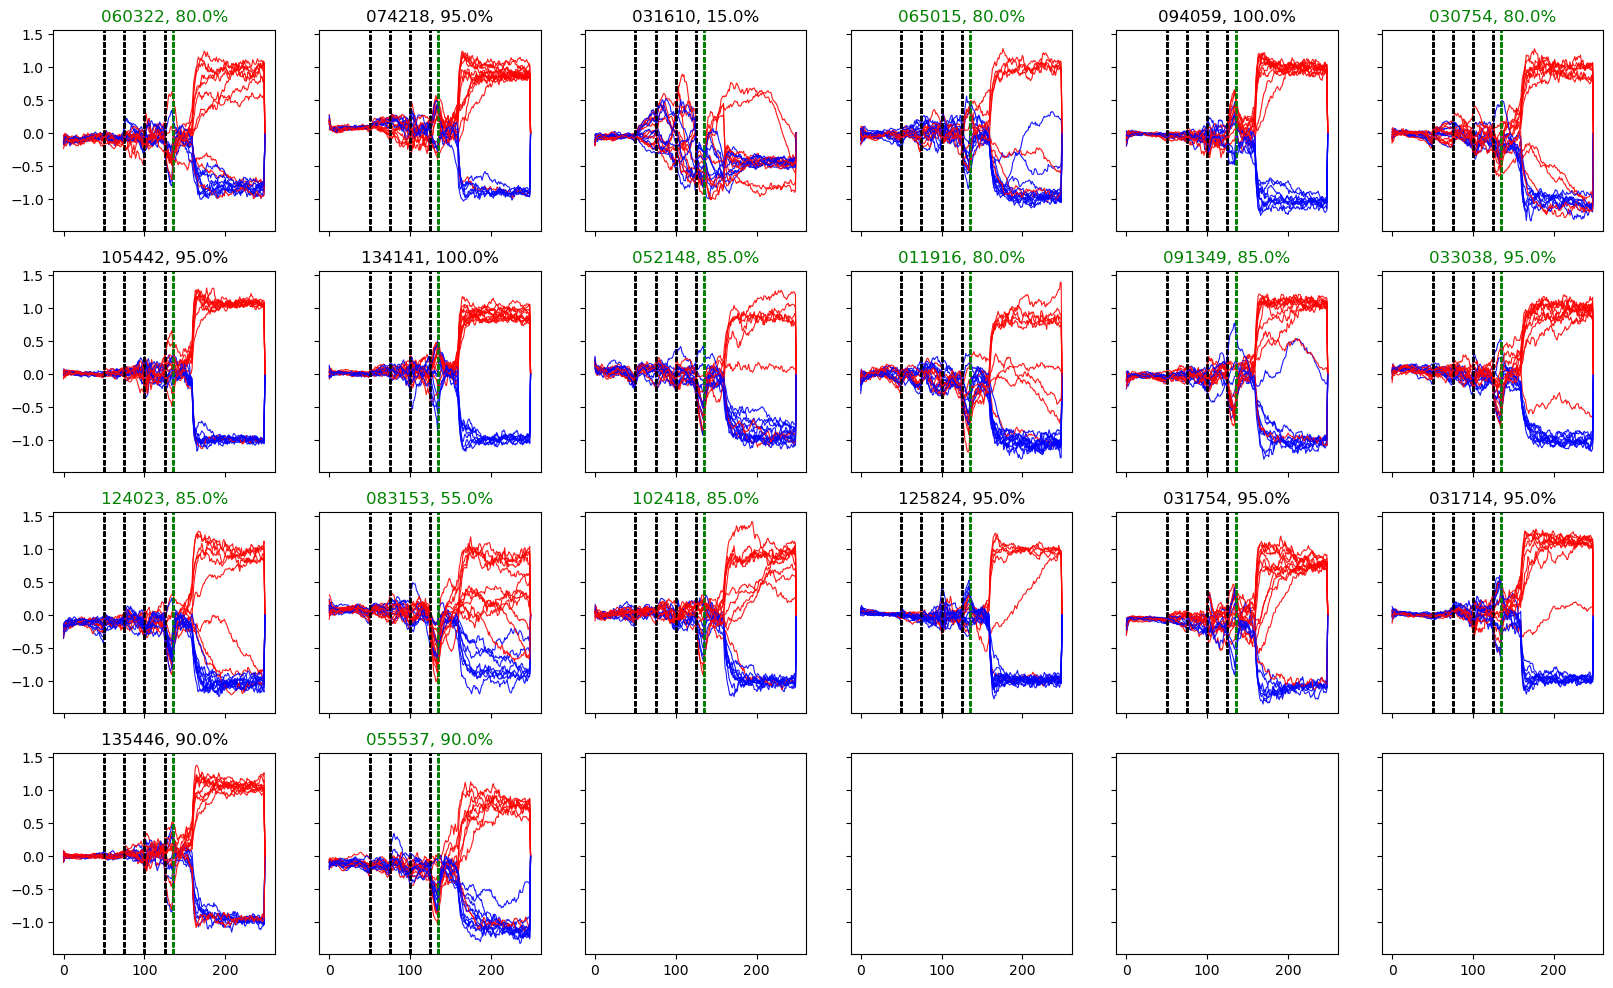

In [6]:
from model import generate_input_stim_sternberg

settings = {
            'T': 250, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 10, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 3, # initialize with load 3
            }

stim_on = mat_data['stim_on_tr'][0]
stim_dur = mat_data['stim_dur_tr'][0]
delay = mat_data['delay_tr'][0]

n_trials = 20
fig, axs = plt.subplots(4, 6, figsize=(20, 12), sharex=True, sharey=True)
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    resp_onset = settings['stim_on'] + settings['load']*settings['stim_dur'] + settings['stim_dur'] + settings['delay']
    eval_perf = np.zeros(n_trials)
    for j in range(n_trials):
        u_high, label = model.generate_input_stim_sternberg(settings)
        x, r, o, _ = model.eval_tf(model_dir=model_name, settings=settings, u=u_high)
        
        if label == 1: # same
            if np.max(o[resp_onset:]) > 0.7:
                eval_perf[j] = 1
        else:
            if np.min(o[resp_onset:]) < -0.7:
                eval_perf[j] = 1    
        axs[i].plot(o, c=['r' if label == 1 else 'b'][0], alpha=0.9, linewidth = 0.8)
        axs[i].axvline(x=stim_on, color='k', linestyle='--', linewidth=1)
        for k in range(settings['load']):
            axs[i].axvline(x=stim_on + (k+1)*stim_dur, color='k', linestyle='--', linewidth=1)
        axs[i].axvline(x=stim_on + stim_dur*settings['load'] + settings['delay'], color='g', linestyle='--', linewidth=1)
    if train_tr[i] < 39999:
        # title color to green
        c_title = 'g'
    else:
        c_title = 'k'
    axs[i].set_title(f'{model_name[-10:-4]}, {np.mean(eval_perf)*100:.1f}%', color=c_title)
plt.show()

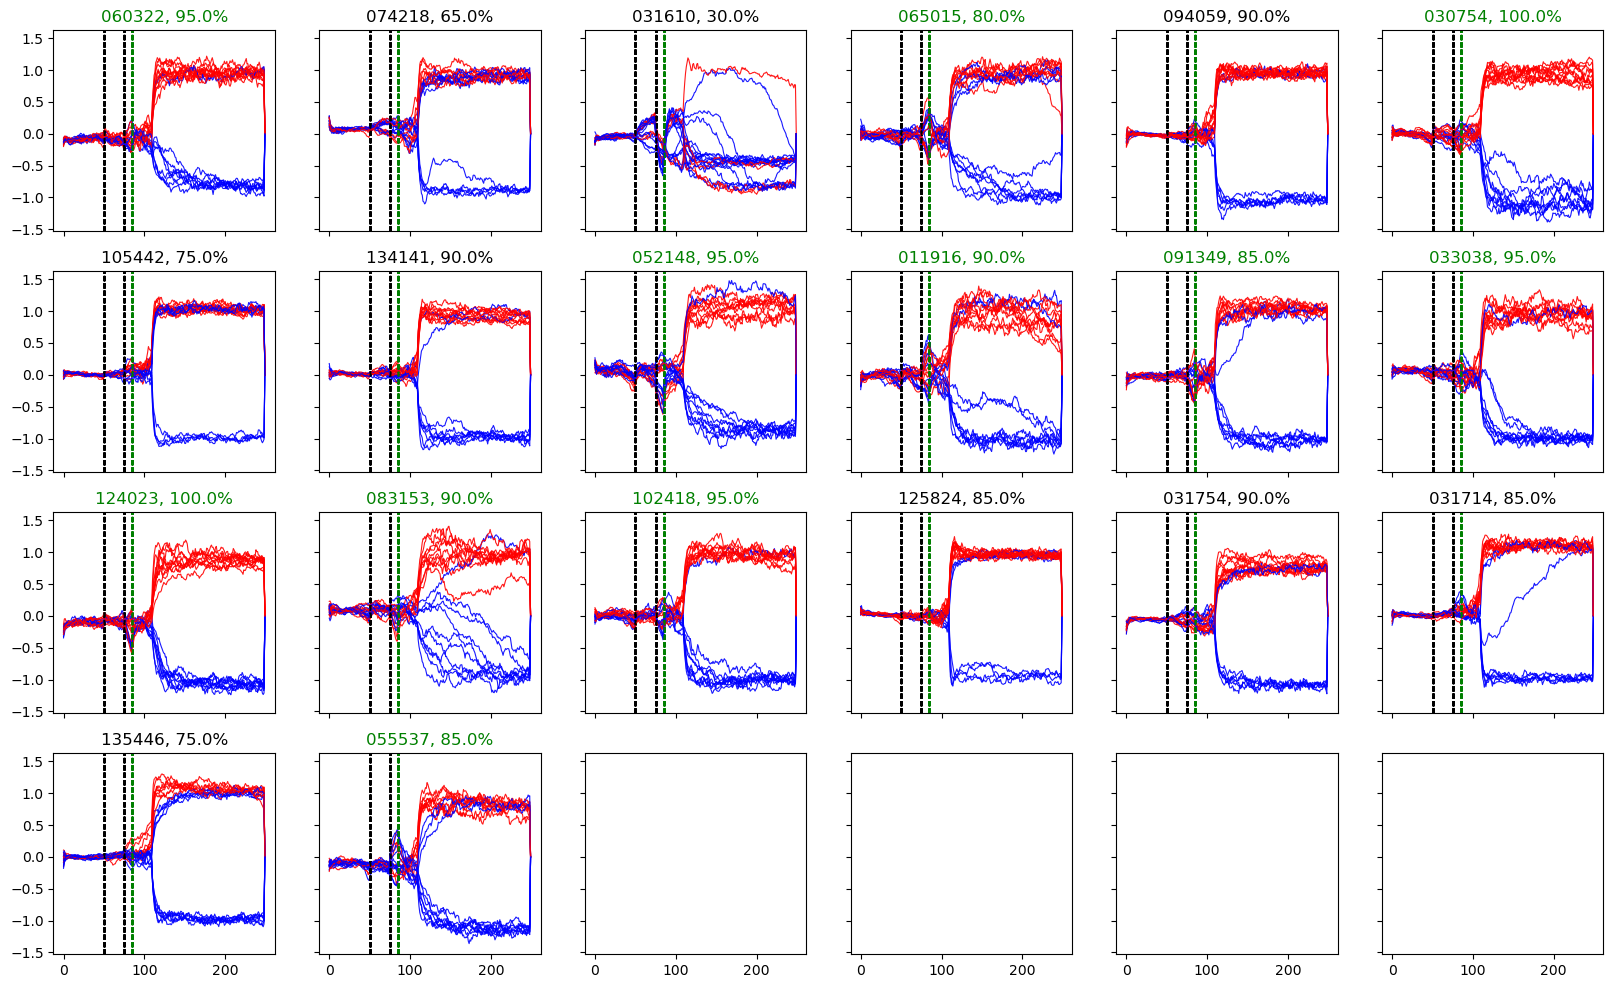

In [7]:
settings = {
            'T': 250, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 10, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 1, # initialize with load 1
            }

stim_on = mat_data['stim_on_tr'][0]
stim_dur = mat_data['stim_dur_tr'][0]
delay = mat_data['delay_tr'][0]

n_trials = 20
fig, axs = plt.subplots(4, 6, figsize=(20, 12), sharex=True, sharey=True)
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    resp_onset = settings['stim_on'] + settings['load']*settings['stim_dur'] + settings['stim_dur'] + settings['delay']
    eval_perf = np.zeros(n_trials)
    for j in range(n_trials):
        u_low, label = model.generate_input_stim_sternberg(settings)
        x, r, o, _ = model.eval_tf(model_dir=model_name, settings=settings, u=u_low)

        if label == 1: # same
            if np.max(o[resp_onset:]) > 0.7:
                eval_perf[j] = 1
        else:
            if np.min(o[resp_onset:]) < -0.7:
                eval_perf[j] = 1
        
        axs[i].plot(o, c=['r' if label == 1 else 'b'][0], alpha=0.9, linewidth = 0.8)
        axs[i].axvline(x=stim_on, color='k', linestyle='--', linewidth=1)
        for k in range(settings['load']):
            axs[i].axvline(x=stim_on + (k+1)*stim_dur, color='k', linestyle='--', linewidth=1)
        axs[i].axvline(x=stim_on + stim_dur*settings['load'] + settings['delay'], color='g', linestyle='--', linewidth=1)
    c_title = 'g' if train_tr[i] < 39999 else 'k'
    axs[i].set_title(f'{model_name[-10:-4]}, {np.mean(eval_perf)*100:.1f}%', color=c_title)
plt.show()

### now extending delay, as a test

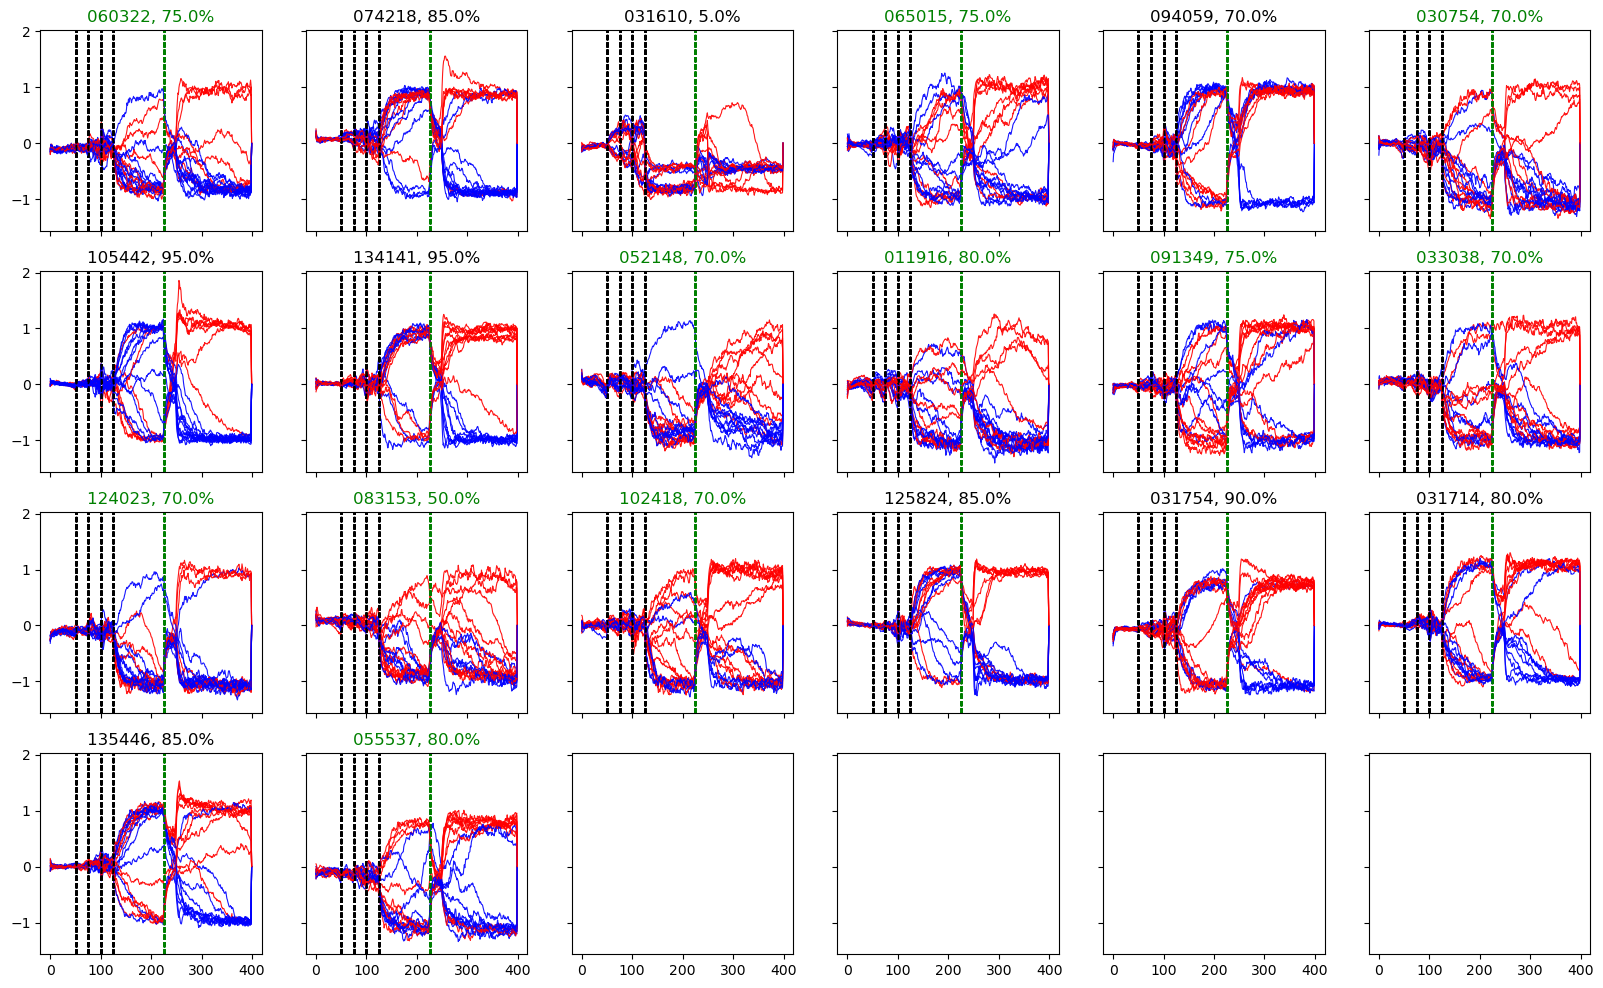

In [8]:
from model import generate_input_stim_sternberg

settings = {
            'T': 400, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 100, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 3, # initialize with load 1, but will alternate with 3
            }

stim_on = mat_data['stim_on_tr'][0]
stim_dur = mat_data['stim_dur_tr'][0]
delay = mat_data['delay_tr'][0]

n_trials = 20
fig, axs = plt.subplots(4, 6, figsize=(20, 12), sharex=True, sharey=True)
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    resp_onset = settings['stim_on'] + settings['load']*settings['stim_dur'] + settings['stim_dur'] + settings['delay']
    eval_perf = np.zeros(n_trials)
    for j in range(n_trials):
        u_high, label = model.generate_input_stim_sternberg(settings)
        x, r, o, _ = model.eval_tf(model_dir=model_name, settings=settings, u=u_high)
        if label == 1: # same
            if np.max(o[resp_onset:]) > 0.7:
                eval_perf[j] = 1
        else:
            if np.min(o[resp_onset:]) < -0.7:
                eval_perf[j] = 1
        
        axs[i].plot(o, c=['r' if label == 1 else 'b'][0], alpha=0.9, linewidth = 0.8)
        axs[i].axvline(x=stim_on, color='k', linestyle='--', linewidth=1)
        for k in range(settings['load']):
            axs[i].axvline(x=stim_on + (k+1)*stim_dur, color='k', linestyle='--', linewidth=1)
        axs[i].axvline(x=stim_on + stim_dur*settings['load'] + settings['delay'], color='g', linestyle='--', linewidth=1)
    c_title = 'g' if train_tr[i] < 39999 else 'k'
    axs[i].set_title(f'{model_name[-10:-4]}, {np.mean(eval_perf)*100:.1f}%', color=c_title)
plt.show()

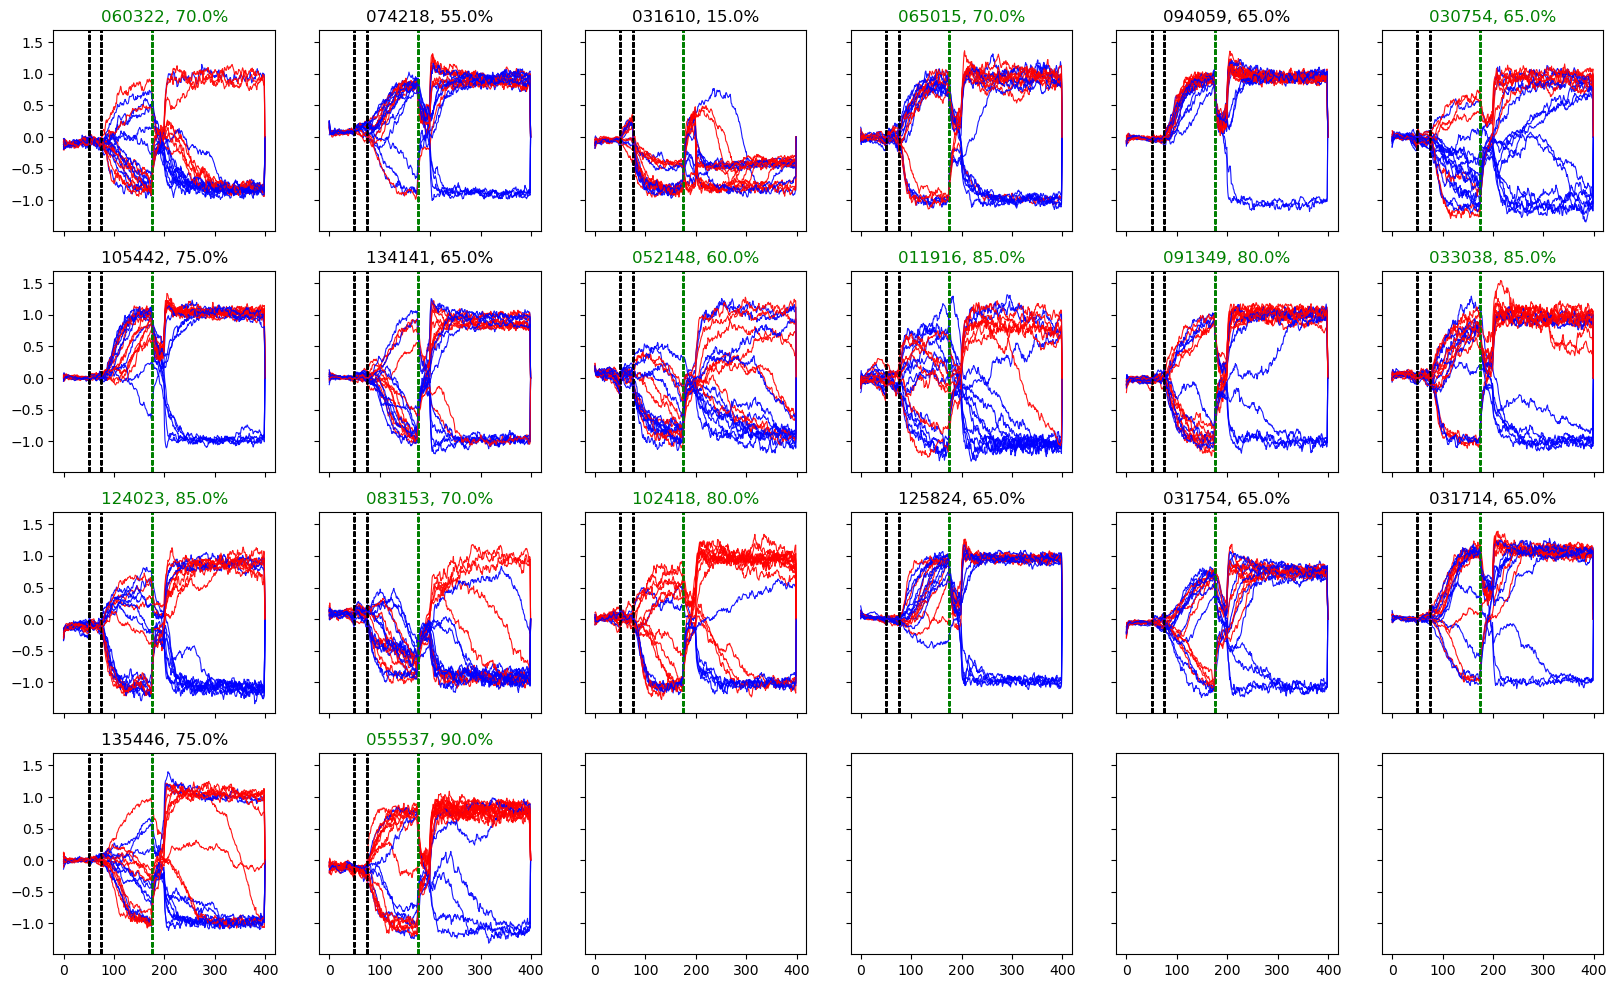

In [9]:
settings = {
            'T': 400, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 100, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 1, # initialize with load 1, but will alternate with 3
            }

stim_on = mat_data['stim_on_tr'][0]
stim_dur = mat_data['stim_dur_tr'][0]
delay = mat_data['delay_tr'][0]

n_trials = 20
fig, axs = plt.subplots(4, 6, figsize=(20, 12), sharex=True, sharey=True)
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    resp_onset = settings['stim_on'] + settings['load']*settings['stim_dur'] + settings['stim_dur'] + settings['delay']
    eval_perf = np.zeros(n_trials)
    for j in range(n_trials):
        u_low, label = model.generate_input_stim_sternberg(settings)
        x, r, o, _ = model.eval_tf(model_dir=model_name, settings=settings, u=u_low)

        if label == 1: # same
            if np.max(o[resp_onset:]) > 0.7:
                eval_perf[j] = 1
        else:
            if np.min(o[resp_onset:]) < -0.7:
                eval_perf[j] = 1
        
        axs[i].plot(o, c=['r' if label == 1 else 'b'][0], alpha=0.9, linewidth = 0.8)
        axs[i].axvline(x=stim_on, color='k', linestyle='--', linewidth=1)
        for k in range(settings['load']):
            axs[i].axvline(x=stim_on + (k+1)*stim_dur, color='k', linestyle='--', linewidth=1)
        axs[i].axvline(x=stim_on + stim_dur*settings['load'] + settings['delay'], color='g', linestyle='--', linewidth=1)
    c_title = 'g' if train_tr[i] < 39999 else 'k'
    axs[i].set_title(f'{model_name[-10:-4]}, {np.mean(eval_perf)*100:.1f}%', color=c_title)
plt.show()

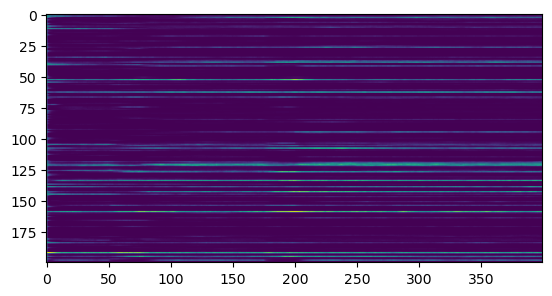

In [ ]:
plt.imshow(r)

## the N=1000 models now

In [1]:
import os, scipy.io 
import numpy as np 
import matplotlib.pyplot as plt 

import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate/')

import model

2026-03-17 23:46:14.237793: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-17 23:46:14.250066: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-17 23:46:14.263104: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-17 23:46:14.267014: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-17 23:46:14.277831: I tensorflow/core/platform/cpu_feature_guar

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
import glob

def find_files(path, pattern):
    """
    Find all files matching the given glob pattern in the specified path
    Args:
        path (str): path to directory
        pattern (str): glob pattern (e.g., '*.xlsx', '*_sorted_new.mat')
    Returns:
        list of file paths
    """
    return glob.glob(os.path.join(path, pattern))

In [3]:
model_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

model_names = find_files(model_dir, '*N_1000*.mat')
print(len(model_names))
print(model_names)

14
['/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_16_220757.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_17_080327.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_17_035156.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_17_205701.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_16_101103.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_17_204450.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_16_210307.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_16_083837.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/

In [4]:
perfs_low = []
perfs_high = []
train_tr = []

for model_name in model_names:
    mat_data = scipy.io.loadmat(os.path.join(model_dir, model_name))
    print(model_name)
    perfs_low.append(mat_data["eval_perfs"][0][0])
    perfs_high.append(mat_data["eval_perfs"][0][1])
    train_tr.append(mat_data["tr"][0])
    print(f'Training trials: {mat_data["tr"][0]}')
    print(f'Load 1 perf: {mat_data["eval_perfs"][0][0]}, Load 3 perf: {mat_data["eval_perfs"][0][1]}')
    print(f'Ending p_low: {mat_data["p_low"][0]}')


/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_16_220757.mat
Training trials: [15401]
Load 1 perf: 0.96, Load 3 perf: 0.89
Ending p_low: [0.5]
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_17_080327.mat
Training trials: [18001]
Load 1 perf: 0.97, Load 3 perf: 0.86
Ending p_low: [0.5]
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_17_035156.mat
Training trials: [28901]
Load 1 perf: 0.97, Load 3 perf: 0.98
Ending p_low: [0.5]
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_17_205701.mat
Training trials: [12901]
Load 1 perf: 0.96, Load 3 perf: 0.82
Ending p_low: [0.5]
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_16_101103.mat
Training trials: [23301]
Load 1 perf: 0.96, Load 3 perf: 0.92
Ending p_low: [0.5]
/home/nuttidalab/Doc

In [5]:
n_complete = 0
for i, tr in enumerate(train_tr):
    if tr < 39999:
        n_complete += 1
        print(f'{model_names[i]}: {tr}')
        print(f'Load 1 perf: {perfs_low[i]}, Load 3 perf: {perfs_high[i]}')

print(f'{n_complete} models have completed training (tr < 39999)')

/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_16_220757.mat: [15401]
Load 1 perf: 0.96, Load 3 perf: 0.89
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_17_080327.mat: [18001]
Load 1 perf: 0.97, Load 3 perf: 0.86
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_17_035156.mat: [28901]
Load 1 perf: 0.97, Load 3 perf: 0.98
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_17_205701.mat: [12901]
Load 1 perf: 0.96, Load 3 perf: 0.82
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_16_101103.mat: [23301]
Load 1 perf: 0.96, Load 3 perf: 0.92
/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_03_17_204450.mat: [14701]
Load 1 perf: 0.97, Load 3 perf: 0.87
/home/nuttidalab/Documents/renee/sternbe

### model eval

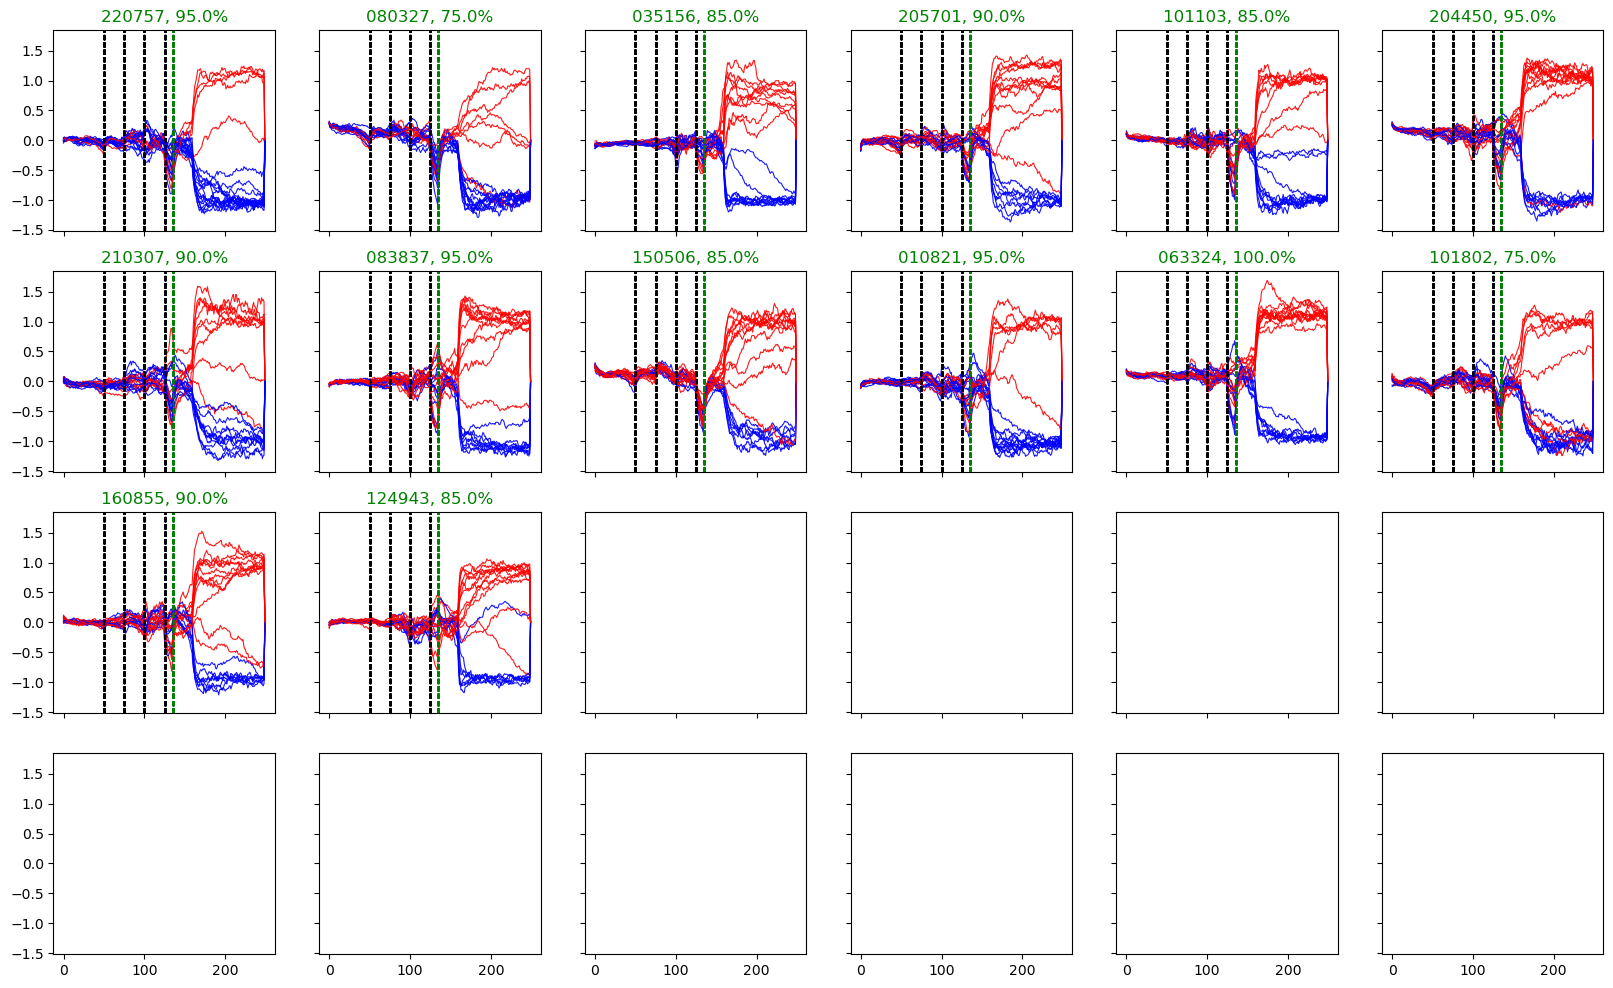

In [6]:
from model import generate_input_stim_sternberg

settings = {
            'T': 250, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 10, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 3, # initialize with load 3
            }

stim_on = mat_data['stim_on_tr'][0]
stim_dur = mat_data['stim_dur_tr'][0]
delay = mat_data['delay_tr'][0]

n_trials = 20
fig, axs = plt.subplots(4, 6, figsize=(20, 12), sharex=True, sharey=True)
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    resp_onset = settings['stim_on'] + settings['load']*settings['stim_dur'] + settings['stim_dur'] + settings['delay']
    eval_perf = np.zeros(n_trials)
    for j in range(n_trials):
        u_high, label = model.generate_input_stim_sternberg(settings)
        x, r, o, _ = model.eval_tf(model_dir=model_name, settings=settings, u=u_high)
        
        if label == 1: # same
            if np.max(o[resp_onset:]) > 0.7:
                eval_perf[j] = 1
        else:
            if np.min(o[resp_onset:]) < -0.7:
                eval_perf[j] = 1    
        axs[i].plot(o, c=['r' if label == 1 else 'b'][0], alpha=0.9, linewidth = 0.8)
        axs[i].axvline(x=stim_on, color='k', linestyle='--', linewidth=1)
        for k in range(settings['load']):
            axs[i].axvline(x=stim_on + (k+1)*stim_dur, color='k', linestyle='--', linewidth=1)
        axs[i].axvline(x=stim_on + stim_dur*settings['load'] + settings['delay'], color='g', linestyle='--', linewidth=1)
    if train_tr[i] < 39999:
        # title color to green
        c_title = 'g'
    else:
        c_title = 'k'
    axs[i].set_title(f'{model_name[-10:-4]}, {np.mean(eval_perf)*100:.1f}%', color=c_title)
plt.show()

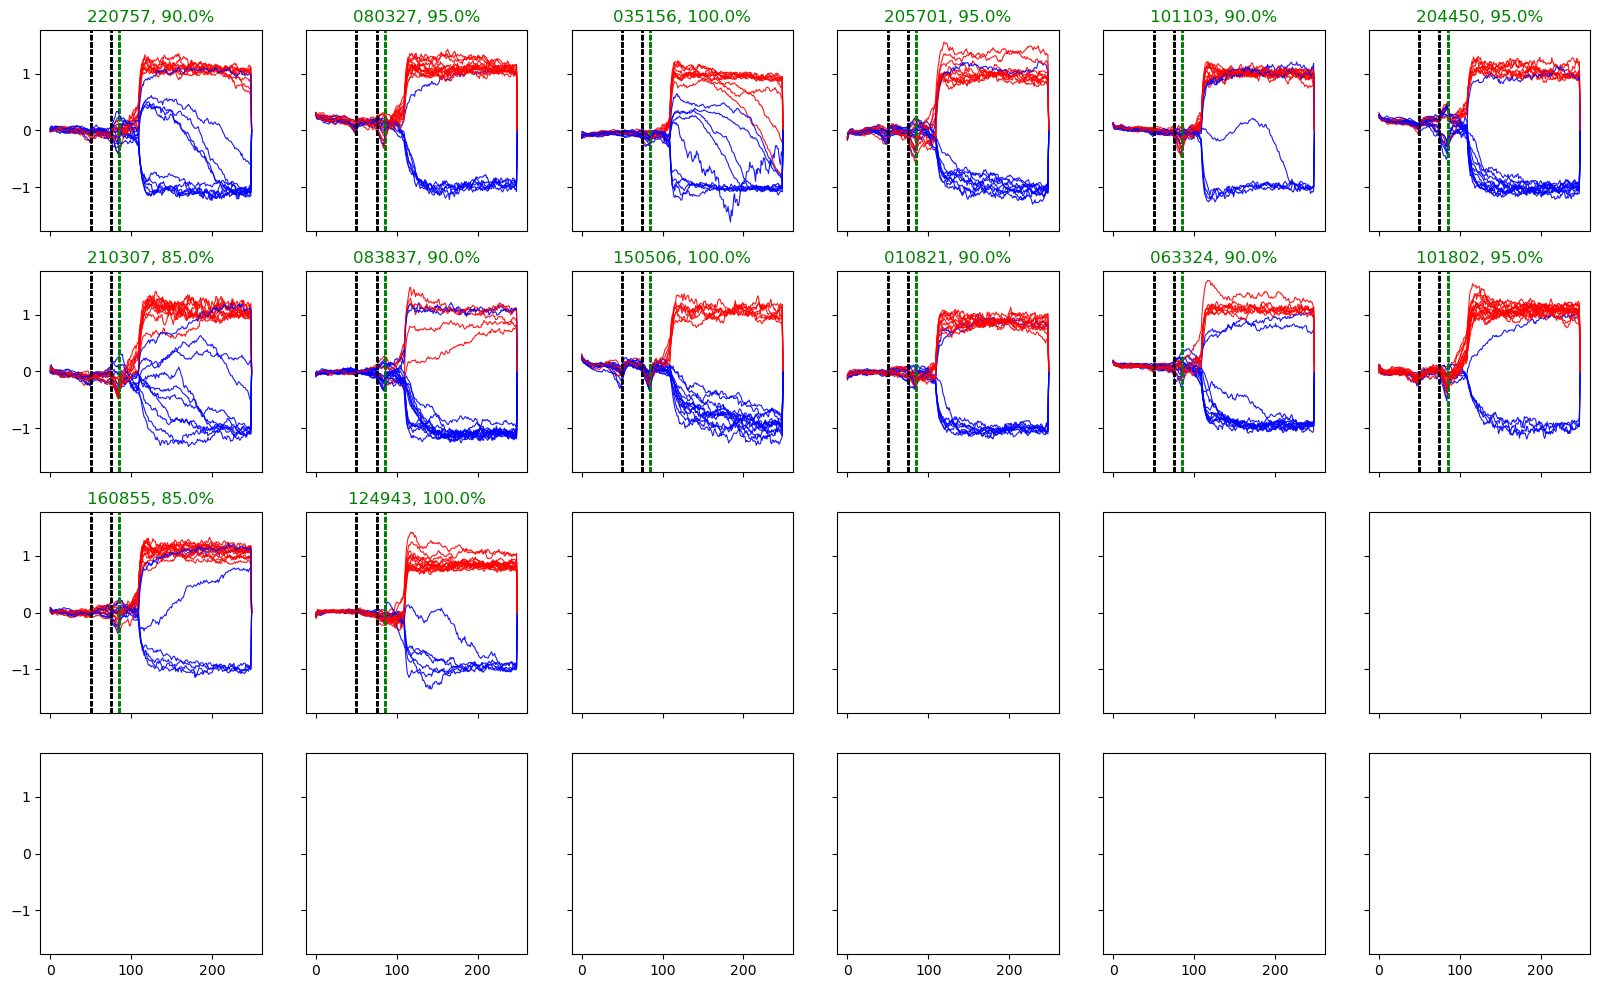

In [7]:
settings = {
            'T': 250, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 10, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 1, # initialize with load 1
            }

stim_on = mat_data['stim_on_tr'][0]
stim_dur = mat_data['stim_dur_tr'][0]
delay = mat_data['delay_tr'][0]

n_trials = 20
fig, axs = plt.subplots(4, 6, figsize=(20, 12), sharex=True, sharey=True)
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    resp_onset = settings['stim_on'] + settings['load']*settings['stim_dur'] + settings['stim_dur'] + settings['delay']
    eval_perf = np.zeros(n_trials)
    for j in range(n_trials):
        u_low, label = model.generate_input_stim_sternberg(settings)
        x, r, o, _ = model.eval_tf(model_dir=model_name, settings=settings, u=u_low)

        if label == 1: # same
            if np.max(o[resp_onset:]) > 0.7:
                eval_perf[j] = 1
        else:
            if np.min(o[resp_onset:]) < -0.7:
                eval_perf[j] = 1
        
        axs[i].plot(o, c=['r' if label == 1 else 'b'][0], alpha=0.9, linewidth = 0.8)
        axs[i].axvline(x=stim_on, color='k', linestyle='--', linewidth=1)
        for k in range(settings['load']):
            axs[i].axvline(x=stim_on + (k+1)*stim_dur, color='k', linestyle='--', linewidth=1)
        axs[i].axvline(x=stim_on + stim_dur*settings['load'] + settings['delay'], color='g', linestyle='--', linewidth=1)
    c_title = 'g' if train_tr[i] < 39999 else 'k'
    axs[i].set_title(f'{model_name[-10:-4]}, {np.mean(eval_perf)*100:.1f}%', color=c_title)
plt.show()

### now extending delay, as a test

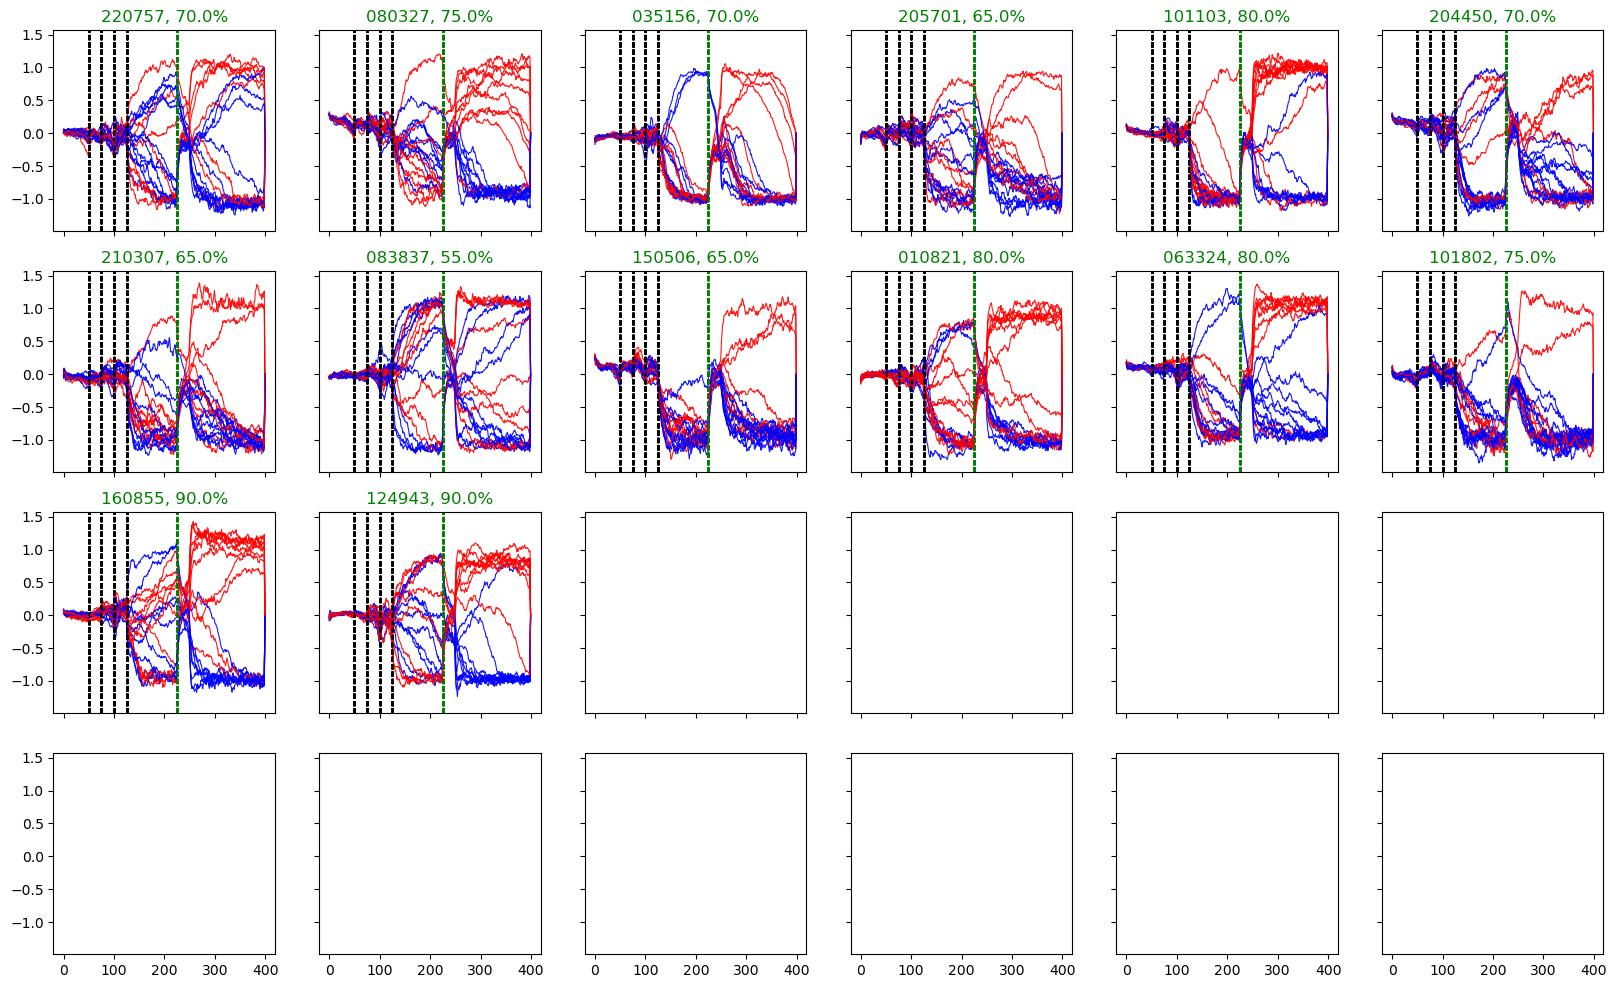

In [8]:
from model import generate_input_stim_sternberg

settings = {
            'T': 400, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 100, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 3, # initialize with load 1, but will alternate with 3
            }

stim_on = mat_data['stim_on_tr'][0]
stim_dur = mat_data['stim_dur_tr'][0]
delay = mat_data['delay_tr'][0]

n_trials = 20
fig, axs = plt.subplots(4, 6, figsize=(20, 12), sharex=True, sharey=True)
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    resp_onset = settings['stim_on'] + settings['load']*settings['stim_dur'] + settings['stim_dur'] + settings['delay']
    eval_perf = np.zeros(n_trials)
    for j in range(n_trials):
        u_high, label = model.generate_input_stim_sternberg(settings)
        x, r, o, _ = model.eval_tf(model_dir=model_name, settings=settings, u=u_high)
        if label == 1: # same
            if np.max(o[resp_onset:]) > 0.7:
                eval_perf[j] = 1
        else:
            if np.min(o[resp_onset:]) < -0.7:
                eval_perf[j] = 1
        
        axs[i].plot(o, c=['r' if label == 1 else 'b'][0], alpha=0.9, linewidth = 0.8)
        axs[i].axvline(x=stim_on, color='k', linestyle='--', linewidth=1)
        for k in range(settings['load']):
            axs[i].axvline(x=stim_on + (k+1)*stim_dur, color='k', linestyle='--', linewidth=1)
        axs[i].axvline(x=stim_on + stim_dur*settings['load'] + settings['delay'], color='g', linestyle='--', linewidth=1)
    c_title = 'g' if train_tr[i] < 39999 else 'k'
    axs[i].set_title(f'{model_name[-10:-4]}, {np.mean(eval_perf)*100:.1f}%', color=c_title)
plt.show()

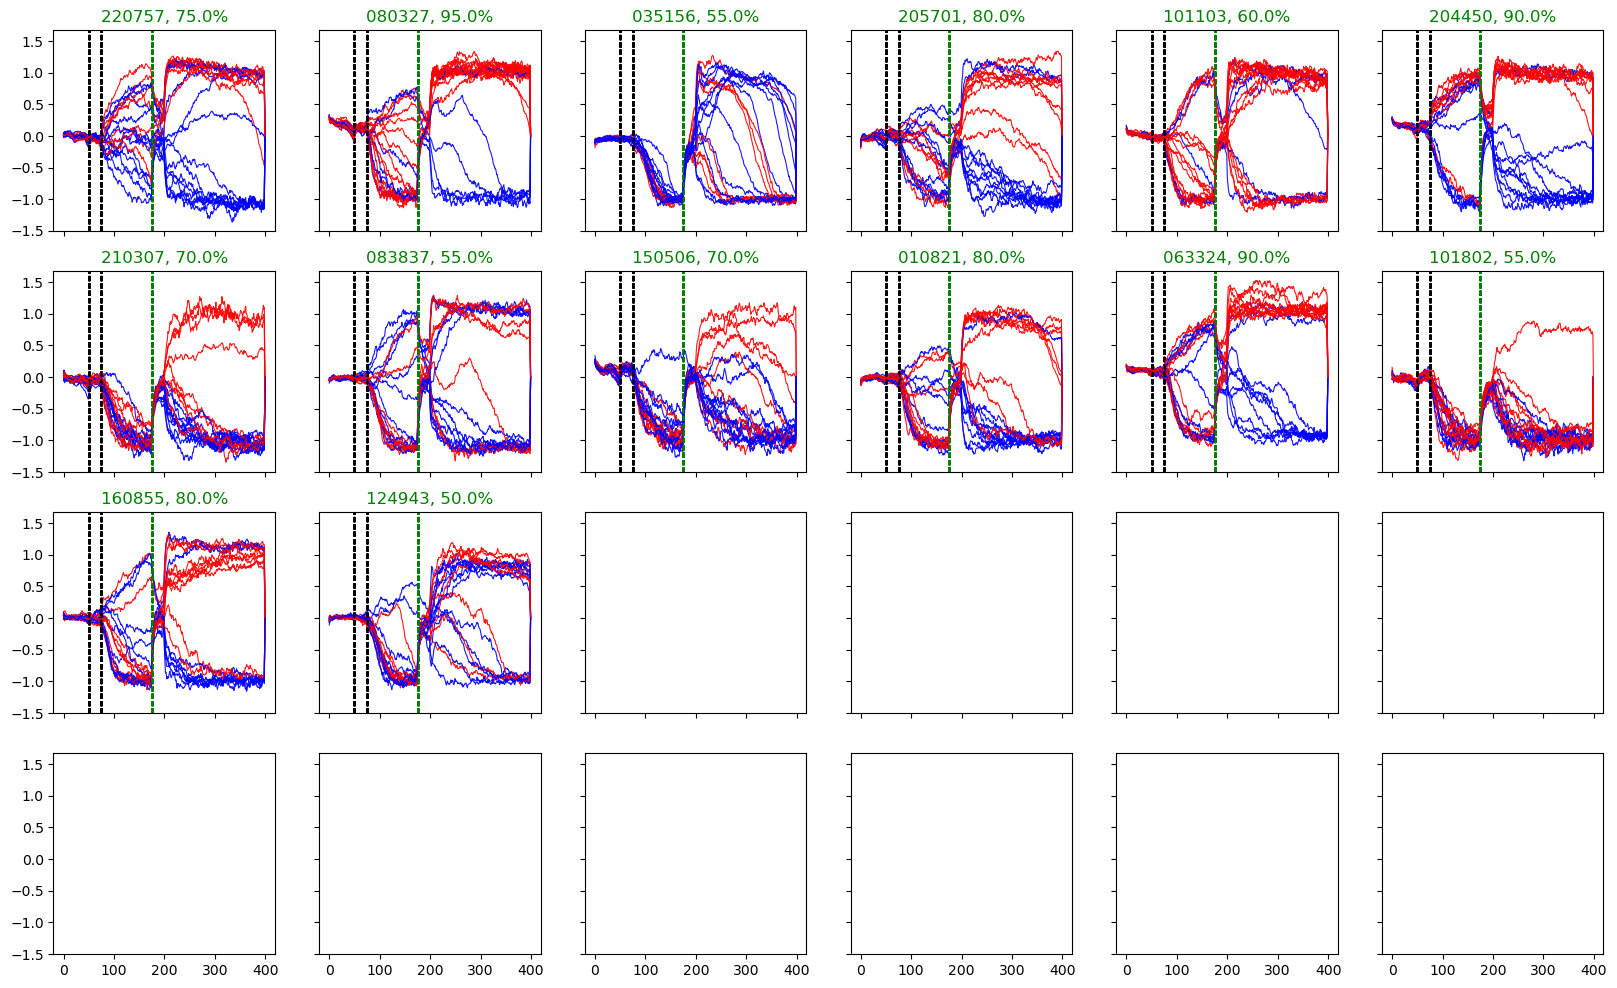

In [9]:
settings = {
            'T': 400, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 100, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 1, # initialize with load 1, but will alternate with 3
            }

stim_on = mat_data['stim_on_tr'][0]
stim_dur = mat_data['stim_dur_tr'][0]
delay = mat_data['delay_tr'][0]

n_trials = 20
fig, axs = plt.subplots(4, 6, figsize=(20, 12), sharex=True, sharey=True)
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    resp_onset = settings['stim_on'] + settings['load']*settings['stim_dur'] + settings['stim_dur'] + settings['delay']
    eval_perf = np.zeros(n_trials)
    for j in range(n_trials):
        u_low, label = model.generate_input_stim_sternberg(settings)
        x, r, o, _ = model.eval_tf(model_dir=model_name, settings=settings, u=u_low)

        if label == 1: # same
            if np.max(o[resp_onset:]) > 0.7:
                eval_perf[j] = 1
        else:
            if np.min(o[resp_onset:]) < -0.7:
                eval_perf[j] = 1
        
        axs[i].plot(o, c=['r' if label == 1 else 'b'][0], alpha=0.9, linewidth = 0.8)
        axs[i].axvline(x=stim_on, color='k', linestyle='--', linewidth=1)
        for k in range(settings['load']):
            axs[i].axvline(x=stim_on + (k+1)*stim_dur, color='k', linestyle='--', linewidth=1)
        axs[i].axvline(x=stim_on + stim_dur*settings['load'] + settings['delay'], color='g', linestyle='--', linewidth=1)
    c_title = 'g' if train_tr[i] < 39999 else 'k'
    axs[i].set_title(f'{model_name[-10:-4]}, {np.mean(eval_perf)*100:.1f}%', color=c_title)
plt.show()

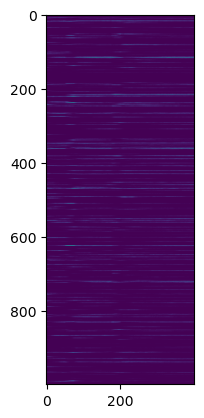

In [10]:
plt.imshow(r)